# Comprehensive Model Evaluation Report for Photocard Classification

This Jupyter Notebook loads a binary classification result CSV file (containing `image_name`, `actual`, `prediction`, and optional `confidence`) and computes:
- **Confusion Matrix 2x2 Table & Seaborn Visual Heatmap Plot**
- **Primary Classification Metrics** (Accuracy, Balanced Accuracy, Precision, Recall, F1-Scores)
- **Derivative Error Rates** (FPR, FNR, FDR, FOR)
- **Probability & Calibration Metrics** (ROC-AUC, PR-AUC, Brier Score)
- **Statistical Agreement Scores** (Matthews Correlation Coefficient, Cohen's Kappa)
- **Confidence Calibration Analysis**
- **Stratified Sub-Group Analysis** (Accuracy by News Genre and News Outlet)
- **Full File Export**: Saves the complete untruncated report to `report.txt` using `with open()`.

## 1. Setup & Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    matthews_corrcoef,
    cohen_kappa_score
)

## 2. Evaluation Function with Full Report Export (`report.txt`)

In [29]:
def evaluate_classification_csv(file_path, output_txt_path="report.txt", plot_matrix=True):
    # 1. Load Dataset
    df = pd.read_csv(file_path)

    # 2. Binary Mapping (Real -> 0, Fake -> 1)
    label_map = {"Real": 0, "Fake": 1}
    df["actual_num"] = df["actual"].map(label_map)
    df["pred_num"] = df["prediction"].map(label_map)

    # 3. Continuous Score for Positive Class (Fake = 1)
    if "confidence" in df.columns:
        df["score_fake"] = df["confidence"].astype(float)

        # Create a true "how sure was the model of its chosen option" column for section 6
        # If it predicted Fake, confidence is score_fake. If Real, confidence is 1 - score_fake.
        df["model_certainty"] = np.where(
            df["prediction"] == "Fake", 
            df["score_fake"], 
            1 - df["score_fake"]
        )
    else:
        df["score_fake"] = df["pred_num"].astype(float)
        df["model_certainty"] = 1.0  # fallback if no confidence array exists

    y_true = df["actual_num"]
    y_pred = df["pred_num"]
    y_score = df["score_fake"]

    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    N = len(df)
    cm_df = pd.DataFrame(cm, index=['Actual Real', 'Actual Fake'], columns=['Pred Real', 'Pred Fake'])

    # Accumulate report output text lines
    report_lines = []
    def log(text=""):
        report_lines.append(text)
        print(text)

    log("=" * 65)
    log("           COMPREHENSIVE MODEL EVALUATION REPORT")
    log("=" * 65)

    log("\n[1] CONFUSION MATRIX TABLE (2x2)")
    log(cm_df.to_string())

    log("\nNumerical Breakdown:")
    log(f" True Negatives  (Actual Real, Pred Real): {TN}")
    log(f" False Positives (Actual Real, Pred Fake): {FP}")
    log(f" False Negatives (Actual Fake, Pred Real): {FN}")
    log(f" True Positives  (Actual Fake, Pred Fake): {TP}")
    log(f" Total Samples Evaluated:                 {N}")

    # --- 2. Primary Classification Metrics ---
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = 0.5 * ((TP / (TP + FN)) + (TN / (TN + FP)))

    prec_fake = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec_fake = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_fake = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    prec_real = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    rec_real = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1_real = f1_score(y_true, y_pred, pos_label=0, zero_division=0)

    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    log("\n[2] PRIMARY CLASSIFICATION METRICS")
    log(f" Accuracy:            {accuracy:.4f}")
    log(f" Balanced Accuracy:   {balanced_acc:.4f}")
    log(f" Macro F1-Score:      {macro_f1:.4f}")
    log(f" Weighted F1-Score:   {weighted_f1:.4f}")
    log("-" * 55)
    log(f" Real Class (0) -> Precision (NPV): {prec_real:.4f}, Recall (Specificity): {rec_real:.4f}, F1: {f1_real:.4f}")
    log(f" Fake Class (1) -> Precision (PPV): {prec_fake:.4f}, Recall (Sensitivity): {rec_fake:.4f}, F1: {f1_fake:.4f}")

    # --- 3. Derivative Error Rates ---
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    fdr = FP / (FP + TP) if (FP + TP) > 0 else 0.0
    for_rate = FN / (FN + TN) if (FN + TN) > 0 else 0.0

    log("\n[3] DERIVATIVE ERROR RATES")
    log(f" False Positive Rate (FPR):    {fpr:.4f}")
    log(f" False Negative Rate (FNR):    {fnr:.4f}")
    log(f" False Discovery Rate (FDR):   {fdr:.4f}")
    log(f" False Omission Rate (FOR):    {for_rate:.4f}")

    # --- 4. Probability & Calibration Metrics ---
    roc_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan
    pr_auc = average_precision_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan
    brier = brier_score_loss(y_true, y_score)

    log("\n[4] PROBABILITY & CALIBRATION METRICS")
    log(f" ROC-AUC Score:                 {roc_auc:.4f}")
    log(f" PR-AUC Score (Avg Precision):  {pr_auc:.4f}")
    log(f" Brier Score Loss:              {brier:.4f}")

    # --- 5. Statistical Agreement Scores ---
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    log("\n[5] STATISTICAL AGREEMENT SCORES")
    log(f" Matthews Correlation Coeff (MCC): {mcc:.4f}")
    log(f" Cohen's Kappa Score:             {kappa:.4f}")

    # --- 6. Confidence Calibration ---
    df["is_correct"] = y_true == y_pred
    if "confidence" in df.columns:
        log("\n[6] CONFIDENCE CALIBRATION ANALYSIS")
        mean_conf_corr = df[df["is_correct"]]["model_certainty"].mean()
        mean_conf_err = df[~df["is_correct"]]["model_certainty"].mean()
        log(f" Mean Confidence (Correct Predictions):   {mean_conf_corr:.4f}")
        log(f" Mean Confidence (Incorrect Predictions): {mean_conf_err:.4f}")

    # --- 7. Stratified Sub-Group Analysis ---
    if "image_name" in df.columns:
        log("\n[7] STRATIFIED SUB-GROUP PERFORMANCE")
        df["outlet_code"] = df["image_name"].apply(
            lambda x: str(x).split("_")[0] if "_" in str(x) else "Unknown"
        )
        df["genre"] = df["image_name"].apply(
            lambda x: (
                str(x).split("_")[2]
                if len(str(x).split("_")) >= 3
                else "Unknown"
            )
        )

        genre_acc = df.groupby("genre")["is_correct"].agg(
            Total="count", Accuracy="mean"
        )
        outlet_acc = df.groupby("outlet_code")["is_correct"].agg(
            Total="count", Accuracy="mean"
        )

        log("\nAccuracy Breakdown by News Genre:")
        log(genre_acc.sort_values(by="Accuracy", ascending=False).to_string())

        log("\nAccuracy Breakdown by News Outlet:")
        log(outlet_acc.sort_values(by="Accuracy", ascending=False).to_string())

    # Save full report to text file using 'with open()'
    with open(output_txt_path, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))
    log(f"\n[+] Full untruncated report successfully saved to '{output_txt_path}'.")

    # --- Visual Heatmap Plot ---
    if plot_matrix:
        plt.figure(figsize=(6, 4.5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                    xticklabels=['Pred Real', 'Pred Fake'],
                    yticklabels=['Actual Real', 'Actual Fake'])
        plt.title('Confusion Matrix Heatmap for Qwen 2.5vl 7B(Baseline)', fontsize=10.5, fontweight='bold') # Qwen 2.5vl 7B (Agentic) --- IGNORE ---
        plt.xlabel('Predicted Label')
        plt.ylabel('Actual Label')
        plt.tight_layout()
        plt.show()

## 3. Execute Model Evaluation & File Export

           COMPREHENSIVE MODEL EVALUATION REPORT

[1] CONFUSION MATRIX TABLE (2x2)
             Pred Real  Pred Fake
Actual Real        208        292
Actual Fake          1        499

Numerical Breakdown:
 True Negatives  (Actual Real, Pred Real): 208
 False Positives (Actual Real, Pred Fake): 292
 False Negatives (Actual Fake, Pred Real): 1
 True Positives  (Actual Fake, Pred Fake): 499
 Total Samples Evaluated:                 1000

[2] PRIMARY CLASSIFICATION METRICS
 Accuracy:            0.7070
 Balanced Accuracy:   0.7070
 Macro F1-Score:      0.6799
 Weighted F1-Score:   0.6799
-------------------------------------------------------
 Real Class (0) -> Precision (NPV): 0.9952, Recall (Specificity): 0.4160, F1: 0.5867
 Fake Class (1) -> Precision (PPV): 0.6308, Recall (Sensitivity): 0.9980, F1: 0.7730

[3] DERIVATIVE ERROR RATES
 False Positive Rate (FPR):    0.5840
 False Negative Rate (FNR):    0.0020
 False Discovery Rate (FDR):   0.3692
 False Omission Rate (FOR):    0.0048

[

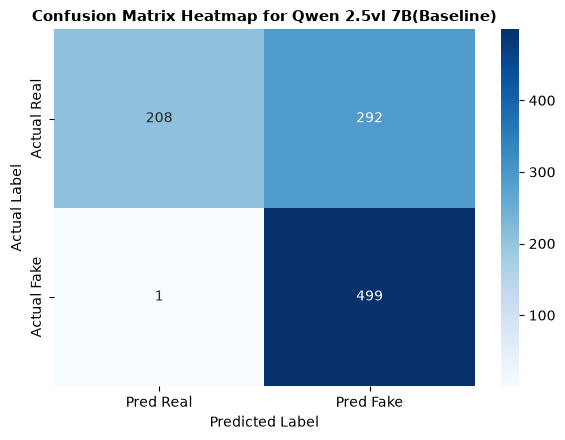

In [ ]:
evaluate_classification_csv('gemini_baseline_result.csv', output_txt_path='gemini_baseline_model_eval_report.txt')

           COMPREHENSIVE MODEL EVALUATION REPORT

[1] CONFUSION MATRIX TABLE (2x2)
             Pred Real  Pred Fake
Actual Real        447         53
Actual Fake        314        186

Numerical Breakdown:
 True Negatives  (Actual Real, Pred Real): 447
 False Positives (Actual Real, Pred Fake): 53
 False Negatives (Actual Fake, Pred Real): 314
 True Positives  (Actual Fake, Pred Fake): 186
 Total Samples Evaluated:                 1000

[2] PRIMARY CLASSIFICATION METRICS
 Accuracy:            0.6330
 Balanced Accuracy:   0.6330
 Macro F1-Score:      0.6062
 Weighted F1-Score:   0.6062
-------------------------------------------------------
 Real Class (0) -> Precision (NPV): 0.5874, Recall (Specificity): 0.8940, F1: 0.7090
 Fake Class (1) -> Precision (PPV): 0.7782, Recall (Sensitivity): 0.3720, F1: 0.5034

[3] DERIVATIVE ERROR RATES
 False Positive Rate (FPR):    0.1060
 False Negative Rate (FNR):    0.6280
 False Discovery Rate (FDR):   0.2218
 False Omission Rate (FOR):    0.4126



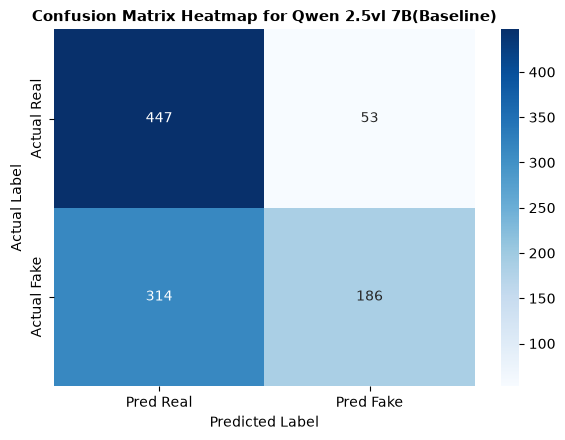

In [ ]:
evaluate_classification_csv('qwen_baseline_result.csv', output_txt_path='qwen_baseline_model_eval_report.txt')

           COMPREHENSIVE MODEL EVALUATION REPORT

[1] CONFUSION MATRIX TABLE (2x2)
             Pred Real  Pred Fake
Actual Real        386        114
Actual Fake          0        500

Numerical Breakdown:
 True Negatives  (Actual Real, Pred Real): 386
 False Positives (Actual Real, Pred Fake): 114
 False Negatives (Actual Fake, Pred Real): 0
 True Positives  (Actual Fake, Pred Fake): 500
 Total Samples Evaluated:                 1000

[2] PRIMARY CLASSIFICATION METRICS
 Accuracy:            0.8860
 Balanced Accuracy:   0.8860
 Macro F1-Score:      0.8845
 Weighted F1-Score:   0.8845
-------------------------------------------------------
 Real Class (0) -> Precision (NPV): 1.0000, Recall (Specificity): 0.7720, F1: 0.8713
 Fake Class (1) -> Precision (PPV): 0.8143, Recall (Sensitivity): 1.0000, F1: 0.8977

[3] DERIVATIVE ERROR RATES
 False Positive Rate (FPR):    0.2280
 False Negative Rate (FNR):    0.0000
 False Discovery Rate (FDR):   0.1857
 False Omission Rate (FOR):    0.0000

[

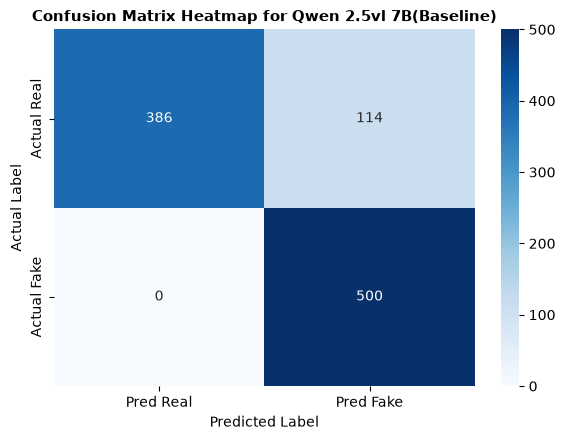

In [ ]:
evaluate_classification_csv('qwen_agentic_verification_results.csv', output_txt_path='qwen_agentic_model_eval_report.txt')

           COMPREHENSIVE MODEL EVALUATION REPORT

[1] CONFUSION MATRIX TABLE (2x2)
             Pred Real  Pred Fake
Actual Real        438         62
Actual Fake          0        500

Numerical Breakdown:
 True Negatives  (Actual Real, Pred Real): 438
 False Positives (Actual Real, Pred Fake): 62
 False Negatives (Actual Fake, Pred Real): 0
 True Positives  (Actual Fake, Pred Fake): 500
 Total Samples Evaluated:                 1000

[2] PRIMARY CLASSIFICATION METRICS
 Accuracy:            0.9380
 Balanced Accuracy:   0.9380
 Macro F1-Score:      0.9378
 Weighted F1-Score:   0.9378
-------------------------------------------------------
 Real Class (0) -> Precision (NPV): 1.0000, Recall (Specificity): 0.8760, F1: 0.9339
 Fake Class (1) -> Precision (PPV): 0.8897, Recall (Sensitivity): 1.0000, F1: 0.9416

[3] DERIVATIVE ERROR RATES
 False Positive Rate (FPR):    0.1240
 False Negative Rate (FNR):    0.0000
 False Discovery Rate (FDR):   0.1103
 False Omission Rate (FOR):    0.0000

[4

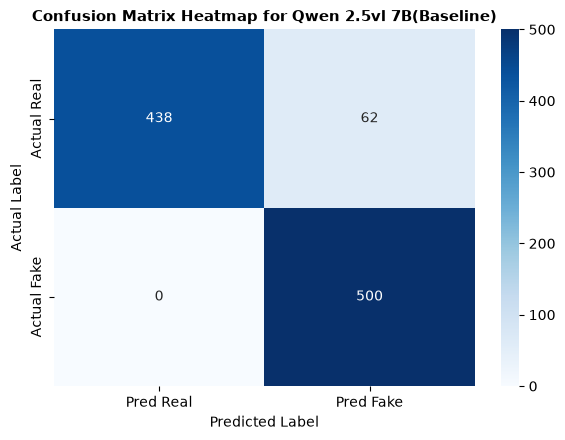

In [ ]:
evaluate_classification_csv('gemini_agentic_verification_results.csv', output_txt_path='gemini_agentic_model_eval_report.txt')